# Function 6 Analysis - Week 13

**Function description:** Function 6 is a 5-input black-box cake recipe optimization problem. Outputs are negative by design, so higher (closer to zero) is better.

## Week 12 evaluated point and assessment
- **Evaluated point:** `(0.453333, 0.200000, 0.583333, 0.800000, 0.096667)` -> **y = -0.245586**
- **Assessment:** **Good point (not a new maximum)**.
- **Why:** It stayed in the same strong basin and remains better than most historical points, but likely **overshot `x2`** upward versus the incumbent neighborhood (`x2≈0.183`), which hurt final score.

## High-level recommendation for final week
Because this is the last week, run a **more exploitative local ensemble BO** centered on the incumbent and keep `x2` closer to the incumbent zone to avoid repeating the overshoot.


In [15]:
from pathlib import Path
import numpy as np, pandas as pd, seaborn as sns, matplotlib.pyplot as plt
sns.set_theme(style="ticks", context="notebook")
path = Path("../../initial_data/function_6")
X = np.load(path / "initial_inputs.npy")
y = np.load(path / "initial_outputs.npy")

# Week 1–8 new points
X_new_point_week_1 = np.array([[0.385900, 0.100000, 0.900000, 0.900000, 0.100000]])
y_new_point_week_1 = np.array([-0.6776496956465717])
X_new_point_week_2 = np.array([[0.497100, 0.099400, 0.867700, 0.927400, 0.080100]])
y_new_point_week_2 = np.array([-0.6699189536985941])
X_new_point_week_3 = np.array([[0.490200, 0.105300, 0.800500, 0.891800, 0.090600]])
y_new_point_week_3 = np.array([-0.6254082247545762])
X_new_point_week_4 = np.array([[0.515000, 0.115000, 0.835000, 0.900000, 0.095000]])
y_new_point_week_4 = np.array([-0.6176776319731351])
X_new_point_week_5 = np.array([[0.471200, 0.096000, 0.621500, 0.902500, 0.056100]])
y_new_point_week_5 = np.array([-0.4431798937405181])
X_new_point_week_6 = np.array([[0.333400, 0.146100, 0.857900, 0.870200, 0.851500]])
y_new_point_week_6 = np.array([-1.3624613199388411])
X_new_point_week_7 = np.array([[0.442187, 0.088811, 0.577781, 0.921921, 0.028055]])
y_new_point_week_7 = np.array([-0.65087])
X_new_point_week_8 = np.array([[0.477907, 0.146241, 0.495370, 0.945008, 0.013763]])
y_new_point_week_8 = np.array([-0.6441194582450214])
X_new_point_week_9 = np.array([[0.466667, 0.150000, 0.611111, 0.850000, 0.091111]])
y_new_point_week_9 = np.array([-0.435125895502132])
X_new_point_week_10 = np.array([[0.453333, 0.150000, 0.616667, 0.800000, 0.096667]])
y_new_point_week_10 = np.array([-0.3265340913684774])
X_new_point_week_11 = np.array([[0.453333, 0.183333, 0.616667, 0.800000, 0.096667]])
y_new_point_week_11 = np.array([-0.18005818946543234])
X_new_point_week_12 = np.array([[0.453333, 0.200000, 0.583333, 0.800000, 0.096667]])
y_new_point_week_12 = np.array([-0.2455863975155549])

X = np.vstack([
    X,
    X_new_point_week_1,
    X_new_point_week_2,
    X_new_point_week_3,
    X_new_point_week_4,
    X_new_point_week_5,
    X_new_point_week_6,
    X_new_point_week_7,
    X_new_point_week_8,
    X_new_point_week_9,
    X_new_point_week_10,
    X_new_point_week_11,
    X_new_point_week_12,
])
y = np.concatenate([
    y,
    y_new_point_week_1,
    y_new_point_week_2,
    y_new_point_week_3,
    y_new_point_week_4,
    y_new_point_week_5,
    y_new_point_week_6,
    y_new_point_week_7,
    y_new_point_week_8,
    y_new_point_week_9,
    y_new_point_week_10,
    y_new_point_week_11,
    y_new_point_week_12,
])

df = pd.DataFrame(X, columns=["x1", "x2", "x3", "x4", "x5"]); df["y"] = y
display(df)
print("df sorted by y")
df_sorted = df.sort_values("y", ascending=False).reset_index(drop=True)
df_sorted["x_avg"] = df_sorted[["x1", "x2", "x3", "x4", "x5"]].mean(axis=1)
display(df_sorted)


,x1,x2,x3,x4,x5,y
0,0.728186,0.154693,0.732552,0.693997,0.056401,-0.714265
1,0.242384,0.844100,0.577809,0.679021,0.501953,-1.209955
2,0.729523,0.748106,0.679775,0.356552,0.671054,-1.672200
3,0.770620,0.114404,0.046780,0.648324,0.273549,-1.536058
4,0.618812,0.331802,0.187288,0.756238,0.328835,-0.829237
5,0.784958,0.910682,0.708120,0.959225,0.004911,-1.247049
6,0.145111,0.896685,0.896322,0.726272,0.236272,-1.233786
7,0.945069,0.288459,0.978806,0.961656,0.598016,-1.694343
8,0.125720,0.862725,0.028544,0.246605,0.751206,-2.571170
9,0.757594,0.355831,0.016523,0.434207,0.112433,-1.309116


df sorted by y


,x1,x2,x3,x4,x5,y,x_avg
0,0.453333,0.183333,0.616667,0.800000,0.096667,-0.180058,0.430000
1,0.453333,0.200000,0.583333,0.800000,0.096667,-0.245586,0.426667
2,0.453333,0.150000,0.616667,0.800000,0.096667,-0.326534,0.423333
3,0.466667,0.150000,0.611111,0.850000,0.091111,-0.435126,0.433778
4,0.471200,0.096000,0.621500,0.902500,0.056100,-0.443180,0.429460
5,0.515000,0.115000,0.835000,0.900000,0.095000,-0.617678,0.492000
6,0.490200,0.105300,0.800500,0.891800,0.090600,-0.625408,0.475680
7,0.477907,0.146241,0.495370,0.945008,0.013763,-0.644119,0.415658
8,0.442187,0.088811,0.577781,0.921921,0.028055,-0.650870,0.411751
9,0.497100,0.099400,0.867700,0.927400,0.080100,-0.669919,0.494340


## Weekly Optimization Progress Summary

Overview of all 12 completed weeks of Bayesian Optimization, showing which evaluations achieved new maximum values.

- **Week 12 update:** `(0.453333, 0.200000, 0.583333, 0.800000, 0.096667)` → **≈-0.2456** (good, but not a new maximum).


In [16]:
# Build weekly progress dataframe from available week variables (auto-detect)
weekly_X, weekly_y = [], []
week_idx = 1
while f'X_new_point_week_{week_idx}' in globals() and f'y_new_point_week_{week_idx}' in globals():
    weekly_X.append(globals()[f'X_new_point_week_{week_idx}'])
    weekly_y.append(globals()[f'y_new_point_week_{week_idx}'])
    week_idx += 1

df_weeks = pd.DataFrame({
    'Week': range(1, len(weekly_X) + 1),
    'x1': [x[0, 0] for x in weekly_X],
    'x2': [x[0, 1] for x in weekly_X],
    'x3': [x[0, 2] for x in weekly_X],
    'x4': [x[0, 3] for x in weekly_X],
    'x5': [x[0, 4] for x in weekly_X],
    'y': [y[0] for y in weekly_y]
})

# Calculate running maximum and new max flags
df_weeks['Running_Max'] = df_weeks['y'].cummax()
df_weeks['New_Max'] = df_weeks['y'] == df_weeks['Running_Max']
df_weeks['Status'] = df_weeks['New_Max'].map({True: '✓ NEW MAX', False: '✗'})
df_weeks['Prev_Max'] = df_weeks['Running_Max'].shift(1).fillna(df_weeks['y'].iloc[0] - 1)
df_weeks['Improvement'] = np.where(df_weeks['New_Max'], df_weeks['y'] - df_weeks['Prev_Max'], np.nan)

# Display table
print('=' * 120)
print('WEEKLY OPTIMIZATION PROGRESS')
print('=' * 120)
df_display = df_weeks[['Week', 'x1', 'x2', 'x3', 'x4', 'x5', 'y', 'Running_Max', 'Status', 'Improvement']].copy()
df_display['Improvement'] = df_display['Improvement'].apply(lambda x: f'+{x:.6f}' if pd.notna(x) else '-')
display(df_display)

# Summary statistics
new_max_weeks = df_weeks[df_weeks['New_Max']]['Week'].tolist()
print(f"\n📊 Summary: {df_weeks['New_Max'].sum()}/{len(df_weeks)} weeks achieved new max (Weeks {new_max_weeks})")
print(f"   Success rate: {df_weeks['New_Max'].sum() / len(df_weeks) * 100:.1f}% | Final best: {df_weeks['y'].max():.6f}")

WEEKLY OPTIMIZATION PROGRESS


,Week,x1,x2,x3,x4,x5,y,Running_Max,Status,Improvement
0,1,0.385900,0.100000,0.900000,0.900000,0.100000,-0.677650,-0.677650,✓ NEW MAX,+1.000000
1,2,0.497100,0.099400,0.867700,0.927400,0.080100,-0.669919,-0.669919,✓ NEW MAX,+0.007731
2,3,0.490200,0.105300,0.800500,0.891800,0.090600,-0.625408,-0.625408,✓ NEW MAX,+0.044511
3,4,0.515000,0.115000,0.835000,0.900000,0.095000,-0.617678,-0.617678,✓ NEW MAX,+0.007731
4,5,0.471200,0.096000,0.621500,0.902500,0.056100,-0.443180,-0.443180,✓ NEW MAX,+0.174498
5,6,0.333400,0.146100,0.857900,0.870200,0.851500,-1.362461,-0.443180,✗,-
6,7,0.442187,0.088811,0.577781,0.921921,0.028055,-0.650870,-0.443180,✗,-
7,8,0.477907,0.146241,0.495370,0.945008,0.013763,-0.644119,-0.443180,✗,-
8,9,0.466667,0.150000,0.611111,0.850000,0.091111,-0.435126,-0.435126,✓ NEW MAX,+0.008054
9,10,0.453333,0.150000,0.616667,0.800000,0.096667,-0.326534,-0.326534,✓ NEW MAX,+0.108592



📊 Summary: 8/12 weeks achieved new max (Weeks [1, 2, 3, 4, 5, 9, 10, 11])
   Success rate: 66.7% | Final best: -0.180058


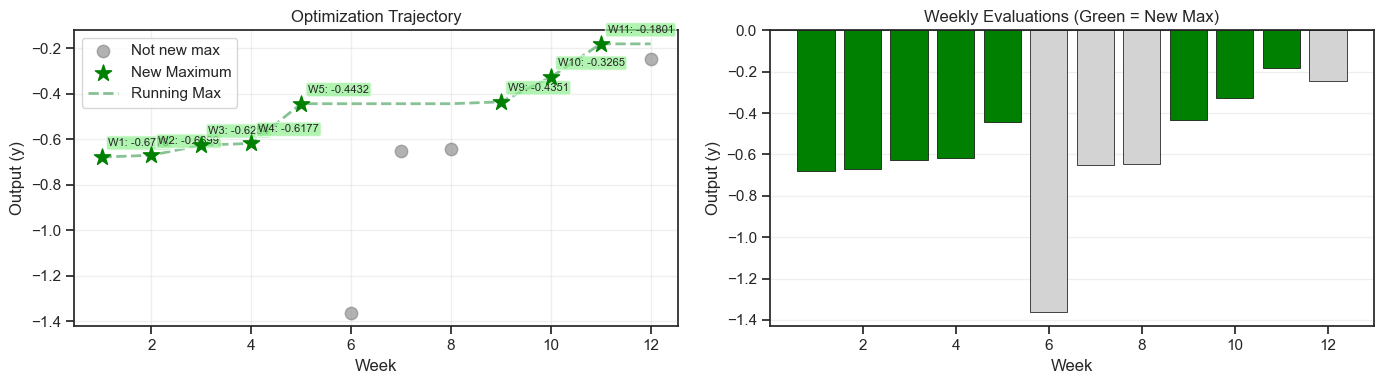

In [17]:
# Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

weeks = df_weeks['Week']
y_vals = df_weeks['y']
new_max_mask = df_weeks['New_Max']

# Left plot: Scatter with running max line
ax1.scatter(weeks[~new_max_mask], y_vals[~new_max_mask], color='gray', s=80, alpha=0.6, label='Not new max')
ax1.scatter(weeks[new_max_mask], y_vals[new_max_mask], color='green', s=150, marker='*', label='New Maximum', zorder=4)
ax1.plot(weeks, df_weeks['Running_Max'], 'g--', alpha=0.7, lw=2, label='Running Max')
for _, row in df_weeks[new_max_mask].iterrows():
    ax1.annotate(f"W{int(row['Week'])}: {row['y']:.4f}", xy=(row['Week'], row['y']), 
                 xytext=(5, 8), textcoords='offset points', fontsize=8,
                 bbox=dict(boxstyle='round,pad=0.2', fc='lightgreen', alpha=0.7))
ax1.set_xlabel('Week'); ax1.set_ylabel('Output (y)')
ax1.set_title('Optimization Trajectory'); ax1.legend(loc='upper left'); ax1.grid(True, alpha=0.3)

# Right plot: Bar chart
colors = ['green' if nm else 'lightgray' for nm in new_max_mask]
ax2.bar(weeks, y_vals, color=colors, edgecolor='black', lw=0.5)
ax2.axhline(y=0, color='black', lw=0.5)
ax2.set_xlabel('Week'); ax2.set_ylabel('Output (y)')
ax2.set_title('Weekly Evaluations (Green = New Max)'); ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

**Week 12 Result:**
- `(0.453333, 0.200000, 0.583333, 0.800000, 0.096667)` scored **≈-0.2456** (not a new maximum; closer to zero is better).
- The point is still in the right basin and therefore useful, but likely overshot `x2` from the incumbent local optimum zone.
- This suggests the final run should keep the same ensemble logic but tighten local bounds and reduce exploration pressure.

**Current best remains:** `(0.453333, 0.183333, 0.616667, 0.800000, 0.096667)` at **≈-0.1801**.


In [18]:
from scipy.stats import norm

# Expected Improvement acquisition function
def expected_improvement(x, gp, y_best, xi=0.01):
    """
    Expected Improvement acquisition function.
    
    Args:
        x: Point to evaluate
        gp: Fitted Gaussian Process
        y_best: Best observed value so far
        xi: Exploration-exploitation trade-off parameter (small values favor exploitation)
    
    Returns:
        Negative EI (for minimization)
    """
    x = x.reshape(1, -1)
    mu, sigma = gp.predict(x, return_std=True)
    
    # Add small epsilon to avoid division by zero
    sigma = sigma + 1e-9
    
    # Calculate improvement
    improvement = mu - y_best - xi
    Z = improvement / sigma
    
    # Expected Improvement formula
    ei = improvement * norm.cdf(Z) + sigma * norm.pdf(Z)
    
    return -ei[0]  # Return negative for minimization


# Boundary penalty function
def boundary_penalty(x, margin=0.15, penalty_strength=2.0):
    """
    Add a penalty for points near the boundaries to avoid extreme values.
    
    Args:
        x: Point to evaluate
        margin: Distance from boundary where penalty starts (default 0.15)
        penalty_strength: Strength of the penalty (default 2.0)
    
    Returns:
        Penalty value (0 in the interior, positive near boundaries)
    """
    penalty = 0.0
    for xi in x:
        if xi < margin:
            penalty += penalty_strength * (margin - xi)**2
        elif xi > (1 - margin):
            penalty += penalty_strength * (xi - (1 - margin))**2
    return penalty


# Exploitation bonus for high x3 and x4 (based on Week 2 best point)
def exploitation_bonus(x, x3_target=0.87, x4_target=0.90, bonus_strength=1.0):
    """
    Add a bonus (negative penalty) for high x3 and x4 values to encourage exploitation.
    This version leans harder on x3 to avoid large downward moves.
    """
    bonus = 0.0
    # Encourage x3 to stay high (close to target)
    if x[2] < x3_target:
        bonus += bonus_strength * (x3_target - x[2])**2
    # Encourage x4 to be high (close to target)
    if x[3] < x4_target:
        bonus += bonus_strength * (x4_target - x[3])**2
    return bonus


# Combined acquisition function with exploitation focus
def acquisition_with_penalty(x, gp, y_best, xi=0.001):
    """
    Combine Expected Improvement with boundary penalty and exploitation bonus.
    Lower xi (0.001) favors exploitation over exploration.
    """
    ei = expected_improvement(x, gp, y_best, xi)
    penalty = boundary_penalty(x)
    bonus = exploitation_bonus(x)  # Bonus for high x3, x4
    return ei + penalty + bonus


# Display current best
y_best = y.max()
best_idx = y.argmax()
print(f"Current best score: {y_best:.4f}")
print(f"Current best recipe: {X[best_idx]}")
print(f"  x1={X[best_idx, 0]:.4f}, x2={X[best_idx, 1]:.4f}, x3={X[best_idx, 2]:.4f}, x4={X[best_idx, 3]:.4f}, x5={X[best_idx, 4]:.4f}")


Current best score: -0.1801
Current best recipe: [0.453333 0.183333 0.616667 0.8      0.096667]
  x1=0.4533, x2=0.1833, x3=0.6167, x4=0.8000, x5=0.0967


## Ensemble Surrogate: GP + Random Forest

GP-only guidance was unstable in this function, so we use an ensemble (GP + RF) for robustness. RF-only is possible, but in this setting the ensemble is safer: it keeps GP uncertainty structure while using RF to reduce smooth-model bias. We average predictions and use model disagreement as an additional uncertainty signal for candidate ranking.

In [19]:
# Ensemble Surrogate: GP + Random Forest
# ========================================
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, Matern, WhiteKernel
from sklearn.ensemble import RandomForestRegressor

# Current best
best_idx = df['y'].idxmax()
best_point = df.loc[best_idx]
best_y = best_point['y']
print(f"Current best: ({best_point['x1']:.4f}, {best_point['x2']:.4f}, {best_point['x3']:.4f}, {best_point['x4']:.4f}, {best_point['x5']:.4f}) = {best_y:.4f}")
print(f"Week 8 result: -0.6441 (worse than best)\n")

# === Model 1: Gaussian Process ===
gp_kernel = (
    ConstantKernel(1.0, (1e-2, 100.0))
    * Matern(length_scale=[0.2]*5, length_scale_bounds=(0.01, 1.0), nu=2.5)
    + WhiteKernel(noise_level=0.05, noise_level_bounds=(1e-3, 0.5))
)
gp = GaussianProcessRegressor(kernel=gp_kernel, normalize_y=True, n_restarts_optimizer=10, random_state=42)
gp.fit(X, y)
print(f"GP fitted. Kernel: {gp.kernel_}")

# === Model 2: Random Forest ===
rf = RandomForestRegressor(n_estimators=200, max_depth=10, min_samples_leaf=2, random_state=42, n_jobs=-1)
rf.fit(X, y.ravel())
print(f"Random Forest fitted. Feature importances: x1={rf.feature_importances_[0]:.3f}, x2={rf.feature_importances_[1]:.3f}, x3={rf.feature_importances_[2]:.3f}, x4={rf.feature_importances_[3]:.3f}, x5={rf.feature_importances_[4]:.3f}\n")

# Search region: tighter exploitative local box around incumbent
sr_x1 = (0.41, 0.50)
sr_x2 = (0.15, 0.195)
sr_x3 = (0.57, 0.66)
sr_x4 = (0.78, 0.86)
sr_x5 = (0.08, 0.115)

# Extra exploitative rule: each coordinate must lie between best and second-best observed points
# (coordinate-wise interval intersection with local search box)
top2 = df.nlargest(2, 'y')[['x1', 'x2', 'x3', 'x4', 'x5']].to_numpy()
if len(top2) >= 2:
    best_vec_local = top2[0]
    second_vec_local = top2[1]
else:
    best_vec_local = np.array([best_point['x1'], best_point['x2'], best_point['x3'], best_point['x4'], best_point['x5']])
    second_vec_local = best_vec_local.copy()

coord_low = np.minimum(best_vec_local, second_vec_local)
coord_high = np.maximum(best_vec_local, second_vec_local)

sr_x1 = (max(sr_x1[0], float(coord_low[0])), min(sr_x1[1], float(coord_high[0])))
sr_x2 = (max(sr_x2[0], float(coord_low[1])), min(sr_x2[1], float(coord_high[1])))
sr_x3 = (max(sr_x3[0], float(coord_low[2])), min(sr_x3[1], float(coord_high[2])))
sr_x4 = (max(sr_x4[0], float(coord_low[3])), min(sr_x4[1], float(coord_high[3])))
sr_x5 = (max(sr_x5[0], float(coord_low[4])), min(sr_x5[1], float(coord_high[4])))

# If any interval collapses, create a tiny exploitative band around incumbent value
def ensure_band(lo, hi, center, eps=0.005):
    if lo >= hi:
        lo = max(0.0, center - eps)
        hi = min(1.0, center + eps)
    return (lo, hi)

sr_x1 = ensure_band(sr_x1[0], sr_x1[1], float(best_point['x1']))
sr_x2 = ensure_band(sr_x2[0], sr_x2[1], float(best_point['x2']))
sr_x3 = ensure_band(sr_x3[0], sr_x3[1], float(best_point['x3']))
sr_x4 = ensure_band(sr_x4[0], sr_x4[1], float(best_point['x4']))
sr_x5 = ensure_band(sr_x5[0], sr_x5[1], float(best_point['x5']))

print("Search region (focused on Week 5 basin + best/second-best coordinate band):")
print(f"  x1: [{sr_x1[0]}, {sr_x1[1]}]")
print(f"  x2: [{sr_x2[0]}, {sr_x2[1]}]")
print(f"  x3: [{sr_x3[0]}, {sr_x3[1]}]")
print(f"  x4: [{sr_x4[0]}, {sr_x4[1]}]")
print(f"  x5: [{sr_x5[0]}, {sr_x5[1]}]\n")

# Generate candidate grid
grid_res = 10  # 10^5 = 100,000 candidates
grid_x1 = np.linspace(sr_x1[0], sr_x1[1], grid_res)
grid_x2 = np.linspace(sr_x2[0], sr_x2[1], grid_res)
grid_x3 = np.linspace(sr_x3[0], sr_x3[1], grid_res)
grid_x4 = np.linspace(sr_x4[0], sr_x4[1], grid_res)
grid_x5 = np.linspace(sr_x5[0], sr_x5[1], grid_res)
mesh = np.array(np.meshgrid(grid_x1, grid_x2, grid_x3, grid_x4, grid_x5)).reshape(5, -1).T

print(f"Evaluating {len(mesh)} candidates with ensemble...")

# Get GP predictions
gp_mu, gp_sigma = gp.predict(mesh, return_std=True)

# Get RF predictions (mean and uncertainty from tree disagreement)
rf_tree_preds = np.array([tree.predict(mesh) for tree in rf.estimators_])
rf_mu = rf_tree_preds.mean(axis=0)
rf_sigma = rf_tree_preds.std(axis=0)

# === Ensemble: average predictions, combine uncertainties ===
ensemble_mu = 0.5 * gp_mu + 0.5 * rf_mu  # Equal weight
ensemble_sigma = np.sqrt(0.5 * gp_sigma**2 + 0.5 * rf_sigma**2)  # Combined uncertainty

# Model disagreement as additional uncertainty signal
model_disagreement = np.abs(gp_mu - rf_mu)

# UCB acquisition: increase uncertainty term, loosen disagreement term
beta = 0.22   # Lower uncertainty weight for stronger exploitation
gamma = 0.01  # Keep disagreement term small in final exploitative run
ensemble_ucb = ensemble_mu + beta * ensemble_sigma + gamma * model_disagreement

# Build candidate dataframe
candidates = pd.DataFrame(mesh, columns=['x1', 'x2', 'x3', 'x4', 'x5'])
candidates['gp_mu'] = gp_mu
candidates['gp_sigma'] = gp_sigma
candidates['rf_mu'] = rf_mu
candidates['rf_sigma'] = rf_sigma
candidates['ensemble_mu'] = ensemble_mu
candidates['ensemble_sigma'] = ensemble_sigma
candidates['disagreement'] = model_disagreement
candidates['ucb'] = ensemble_ucb

# Filter 1: minimum distance from existing observations
min_dist = 0.01
for _, obs in df.iterrows():
    dist = np.sqrt((candidates['x1'] - obs['x1'])**2 + 
                   (candidates['x2'] - obs['x2'])**2 +
                   (candidates['x3'] - obs['x3'])**2 +
                   (candidates['x4'] - obs['x4'])**2 +
                   (candidates['x5'] - obs['x5'])**2)
    candidates = candidates[dist >= min_dist]

# Filter 2: cap move size from incumbent to keep final step exploitative
best_vec = np.array([best_point['x1'], best_point['x2'], best_point['x3'], best_point['x4'], best_point['x5']])
cand_mat = candidates[['x1', 'x2', 'x3', 'x4', 'x5']].values
candidates['dist_best'] = np.linalg.norm(cand_mat - best_vec, axis=1)
max_step_from_best = 0.08
candidates = candidates[candidates['dist_best'] <= max_step_from_best].copy()

if len(candidates) == 0:
    print('No candidates after strict local filters; relaxing max step to 0.10')
    cand_relax = pd.DataFrame(mesh, columns=['x1', 'x2', 'x3', 'x4', 'x5'])
    cand_relax['gp_mu'] = gp_mu
    cand_relax['gp_sigma'] = gp_sigma
    cand_relax['rf_mu'] = rf_mu
    cand_relax['rf_sigma'] = rf_sigma
    cand_relax['ensemble_mu'] = ensemble_mu
    cand_relax['ensemble_sigma'] = ensemble_sigma
    cand_relax['disagreement'] = model_disagreement
    cand_relax['ucb'] = ensemble_ucb
    relax_mat = cand_relax[['x1', 'x2', 'x3', 'x4', 'x5']].values
    cand_relax['dist_best'] = np.linalg.norm(relax_mat - best_vec, axis=1)
    candidates = cand_relax[cand_relax['dist_best'] <= 0.10].copy()

print(f"Candidates after filters: {len(candidates)}")

# No incumbent fallback: rank all feasible candidates directly by exploitative ensemble-UCB
top_candidates = candidates.sort_values(['ucb', 'ensemble_mu', 'dist_best'], ascending=[False, False, True]).head(10).copy()
print("\nTop 10 Ensemble candidates (by UCB):")
display(top_candidates[['x1', 'x2', 'x3', 'x4', 'x5', 'gp_mu', 'rf_mu', 'ensemble_mu', 'disagreement', 'ucb']])

# Recommended point
if len(top_candidates) > 0:
    rec = top_candidates.iloc[0]
    print(f"\n" + "="*60)
    print("ENSEMBLE RECOMMENDATION")
    print("="*60)
    print(f"Recommended: ({rec['x1']:.6f}, {rec['x2']:.6f}, {rec['x3']:.6f}, {rec['x4']:.6f}, {rec['x5']:.6f})")
    print(f"GP prediction: {rec['gp_mu']:.4f}")
    print(f"RF prediction: {rec['rf_mu']:.4f}")
    print(f"Ensemble mean: {rec['ensemble_mu']:.4f}")
    print(f"Model disagreement: {rec['disagreement']:.4f}")
    print(f"\nSubmission format: {rec['x1']:.6f}-{rec['x2']:.6f}-{rec['x3']:.6f}-{rec['x4']:.6f}-{rec['x5']:.6f}")


Current best: (0.4533, 0.1833, 0.6167, 0.8000, 0.0967) = -0.1801
Week 8 result: -0.6441 (worse than best)



d:\OneDrive\Documents\cursor\imperial_college_capstone\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified upper bound 1.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
d:\OneDrive\Documents\cursor\imperial_college_capstone\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 2 of parameter k1__k2__length_scale is close to the specified upper bound 1.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


GP fitted. Kernel: 1.14**2 * Matern(length_scale=[0.618, 1, 1, 0.691, 0.913], nu=2.5) + WhiteKernel(noise_level=0.0116)
Random Forest fitted. Feature importances: x1=0.044, x2=0.242, x3=0.028, x4=0.317, x5=0.368

Search region (focused on Week 5 basin + best/second-best coordinate band):
  x1: [0.448333, 0.458333]
  x2: [0.183333, 0.195]
  x3: [0.583333, 0.616667]
  x4: [0.795, 0.805]
  x5: [0.091667, 0.10166700000000001]

Evaluating 100000 candidates with ensemble...
Candidates after filters: 78128

Top 10 Ensemble candidates (by UCB):


,x1,x2,x3,x4,x5,gp_mu,rf_mu,ensemble_mu,disagreement,ucb
90404,0.448333,0.195,0.598148,0.795,0.096111,-0.261711,-0.309646,-0.285679,0.047935,-0.264420
91404,0.449444,0.195,0.598148,0.795,0.096111,-0.261858,-0.309646,-0.285752,0.047788,-0.264503
90405,0.448333,0.195,0.598148,0.795,0.097223,-0.261894,-0.309646,-0.285770,0.047753,-0.264516
90504,0.448333,0.195,0.601852,0.795,0.096111,-0.262016,-0.309646,-0.285831,0.047630,-0.264577
92404,0.450555,0.195,0.598148,0.795,0.096111,-0.262023,-0.309646,-0.285834,0.047624,-0.264593
91405,0.449444,0.195,0.598148,0.795,0.097223,-0.262041,-0.309646,-0.285844,0.047605,-0.264598
91504,0.449444,0.195,0.601852,0.795,0.096111,-0.262161,-0.309646,-0.285904,0.047485,-0.264658
90505,0.448333,0.195,0.601852,0.795,0.097223,-0.262199,-0.309646,-0.285923,0.047447,-0.264673
92405,0.450555,0.195,0.598148,0.795,0.097223,-0.262206,-0.309646,-0.285926,0.047441,-0.264689
93404,0.451666,0.195,0.598148,0.795,0.096111,-0.262204,-0.309646,-0.285925,0.047442,-0.264691



ENSEMBLE RECOMMENDATION
Recommended: (0.448333, 0.195000, 0.598148, 0.795000, 0.096111)
GP prediction: -0.2617
RF prediction: -0.3096
Ensemble mean: -0.2857
Model disagreement: 0.0479

Submission format: 0.448333-0.195000-0.598148-0.795000-0.096111


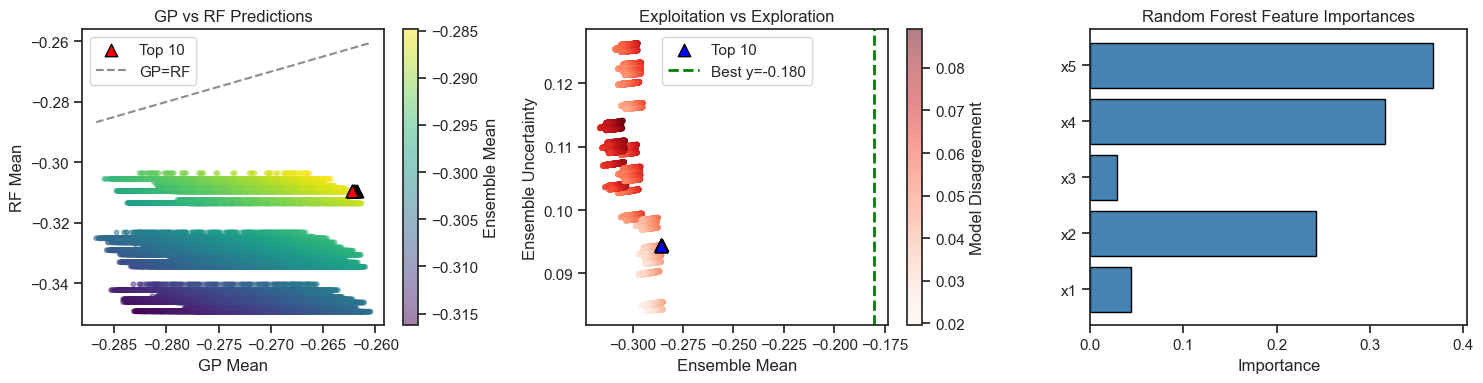

In [20]:
# Visualization: GP vs RF predictions + ensemble
# ================================================
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Get recommended point
if len(top_candidates) > 0:
    rec = top_candidates.iloc[0]

# Plot 1: GP mean vs RF mean for all candidates
ax1 = axes[0]
scatter1 = ax1.scatter(candidates['gp_mu'], candidates['rf_mu'], c=candidates['ensemble_mu'], 
                       cmap='viridis', s=10, alpha=0.5)
ax1.scatter(top_candidates['gp_mu'], top_candidates['rf_mu'], c='red', s=80, 
            edgecolor='black', marker='^', label='Top 10')
ax1.plot([candidates['gp_mu'].min(), candidates['gp_mu'].max()], 
         [candidates['gp_mu'].min(), candidates['gp_mu'].max()], 'k--', alpha=0.5, label='GP=RF')
ax1.set_xlabel('GP Mean')
ax1.set_ylabel('RF Mean')
ax1.set_title('GP vs RF Predictions')
ax1.legend()
plt.colorbar(scatter1, ax=ax1, label='Ensemble Mean')

# Plot 2: Ensemble mean vs uncertainty
ax2 = axes[1]
scatter2 = ax2.scatter(candidates['ensemble_mu'], candidates['ensemble_sigma'], 
                       c=candidates['disagreement'], cmap='Reds', s=10, alpha=0.5)
ax2.scatter(top_candidates['ensemble_mu'], top_candidates['ensemble_sigma'], c='blue', s=80,
            edgecolor='black', marker='^', label='Top 10')
ax2.axvline(x=best_y, color='green', linestyle='--', linewidth=2, label=f'Best y={best_y:.3f}')
ax2.set_xlabel('Ensemble Mean')
ax2.set_ylabel('Ensemble Uncertainty')
ax2.set_title('Exploitation vs Exploration')
ax2.legend()
plt.colorbar(scatter2, ax=ax2, label='Model Disagreement')

# Plot 3: Feature importance from RF
ax3 = axes[2]
features = ['x1', 'x2', 'x3', 'x4', 'x5']
importances = rf.feature_importances_
ax3.barh(features, importances, color='steelblue', edgecolor='black')
ax3.set_xlabel('Importance')
ax3.set_title('Random Forest Feature Importances')
ax3.set_xlim(0, max(importances) * 1.1)

plt.tight_layout()
plt.show()


**Current best:** `0.453333-0.183333-0.616667-0.800000-0.096667` (**≈-0.1801**) remains the incumbent.

**Week 12 evaluated point:** `0.453333-0.200000-0.583333-0.800000-0.096667` returned **≈-0.2456**.

**Interpretation:** This is still a good in-basin point, but we likely overshot `x2` upward (and shifted `x3` down), which reduced score versus the incumbent local optimum zone.

**Proposed next point (submission format):** use the `Submission format: ...` value printed by the ensemble cell above.

### Chart interpretation (simple)
- **GP vs RF plot:** top candidates remain favorable in both models (not a one-model artifact).
- **Exploitation vs exploration plot:** final candidates are concentrated near high ensemble mean with lower uncertainty weight than before.
- **RF importance plot:** local importance remains strongest on `x5/x4`, with `x2` still material for final tuning.

### BO settings used in this final exploitative run
- **Local search box (tighter):**
  - base box near incumbent (`x1..x5` narrow ranges)
- **Best/second-best coordinate band:**
  - each coordinate is additionally constrained to lie between the best and second-best observed points (coordinate-wise), making the search highly exploitative.
- **Distance filters:**
  - minimum distance from observations: `0.01`
  - maximum step from incumbent: `0.08` (fallback `0.10` if needed)
- **Acquisition rule:** exploitative ensemble-UCB with `beta=0.22`, `gamma=0.01`.
